In [58]:
import json
import pandas as pd

# Load JSONL file
def load_jsonl(path):
    data = []
    with open(path, "r") as f:
        for line in f:
            data.append(json.loads(line))
    return pd.DataFrame(data)

train_df = load_jsonl("data/processed/train.jsonl")
val_df = load_jsonl("data/processed/validation.jsonl")

print("Train size:", len(train_df))
print("Validation size:", len(val_df))

train_df.head()

Train size: 4877
Validation size: 610


,instruction,output,source
0,You are a cautious medical AI assistant. Provi...,Hello! The diaphragm is the primary muscle inv...,chatdoctor
1,You are a cautious medical AI assistant. Provi...,It is unlikely that your partner will become p...,chatdoctor
2,You are a cautious medical AI assistant. Provi...,"Hello! Based on your reports, everything seems...",chatdoctor
3,You are a cautious medical AI assistant. Provi...,"As an AI language model, I cannot diagnose med...",chatdoctor
4,You are a cautious medical AI assistant. Provi...,"Yes, it is advised that you seek immediate med...",chatdoctor


In [59]:
print(train_df.columns)
# Check missing values
print(train_df.isnull().sum())

Index(['instruction', 'output', 'source'], dtype='object')
instruction    0
output         0
source         0
dtype: int64


In [60]:
# Length functions
train_df["instruction_len"] = train_df["instruction"].apply(lambda x: len(x.split()))
train_df["response_len"] = train_df["output"].apply(lambda x: len(x.split()))

val_df["instruction_len"] = val_df["instruction"].apply(lambda x: len(x.split()))
val_df["response_len"] = val_df["output"].apply(lambda x: len(x.split()))

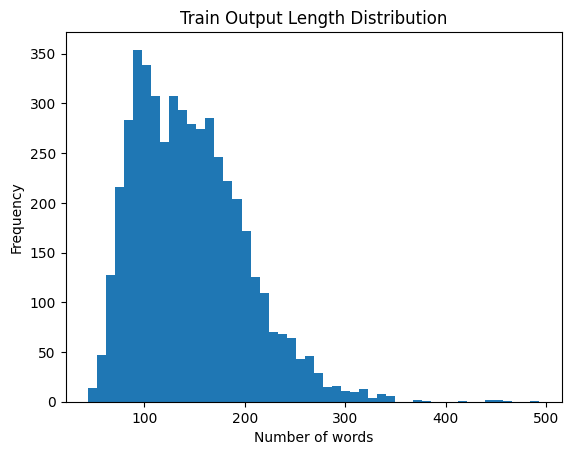

In [61]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(train_df["response_len"], bins=50)
plt.title("Train Output Length Distribution")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

In [62]:
print("Train Output Length Stats:")
print(train_df["response_len"].describe())

print("\nValidation Output Length Stats:")
print(val_df["response_len"].describe())

Train Output Length Stats:
count    4877.000000
mean      145.822637
std        55.058142
min        44.000000
25%       102.000000
50%       139.000000
75%       180.000000
max       493.000000
Name: response_len, dtype: float64

Validation Output Length Stats:
count    610.000000
mean     141.729508
std       51.373969
min       40.000000
25%      102.000000
50%      138.000000
75%      174.000000
max      320.000000
Name: response_len, dtype: float64


In [63]:
long_outputs = train_df[train_df["response_len"] > 200]

print("Number of long outputs (>200 words):", len(long_outputs))
long_outputs.head(5)

Number of long outputs (>200 words): 739


,instruction,output,source,instruction_len,response_len
0,You are a cautious medical AI assistant. Provi...,Hello! The diaphragm is the primary muscle inv...,chatdoctor,151,208
37,You are a cautious medical AI assistant. Provi...,"Yes, I can explain the semen analysis results ...",chatdoctor,45,203
38,You are a cautious medical AI assistant. Provi...,"Hello! Based on the values you provided, it ap...",chatdoctor,48,252
45,You are a cautious medical AI assistant. Provi...,Thank you for your question. Given your recent...,chatdoctor,83,217
46,You are a cautious medical AI assistant. Provi...,"Hello, I understand your concerns about taking...",chatdoctor,112,213


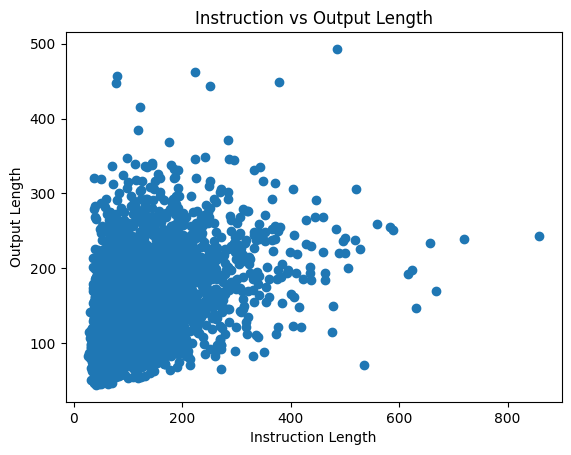

In [64]:
plt.figure()
plt.scatter(train_df["instruction_len"], train_df["response_len"])
plt.xlabel("Instruction Length")
plt.ylabel("Output Length")
plt.title("Instruction vs Output Length")
plt.show()

In [65]:
short_outputs = train_df[train_df["response_len"] < 50]

print("Short outputs count:", len(short_outputs))
short_outputs.head()

Short outputs count: 8


,instruction,output,source,instruction_len,response_len
418,You are a cautious medical AI assistant. Provi...,Hello! I'm happy to help with your query. Coul...,chatdoctor,36,49
646,You are a cautious medical AI assistant. Provi...,"Hello, I am an AI language model and cannot di...",chatdoctor,46,45
1935,You are a cautious medical AI assistant. Provi...,Hello! I'm happy to help you with your skin co...,chatdoctor,70,46
2036,You are a cautious medical AI assistant. Provi...,"Dear patient,\n\nAs an AI language model, I am...",chatdoctor,51,45
2262,You are a cautious medical AI assistant. Provi...,"Hello,\n\nAs an AI language model, I do not ha...",chatdoctor,46,47


In [66]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("models/qwen3.5-0.8b-chatdoctor-unsloth")

train_df["output_tokens"] = train_df["output"].apply(lambda x: len(tokenizer.encode(x)))

print(train_df["output_tokens"].describe())

The tokenizer you are loading from 'models/qwen3.5-0.8b-chatdoctor-unsloth' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


count    4877.000000
mean      180.222063
std        72.203378
min        49.000000
25%       122.000000
50%       173.000000
75%       226.000000
max       612.000000
Name: output_tokens, dtype: float64


In [67]:
short_outputs = train_df[train_df["response_len"] < 60]

print("Short outputs count:", len(short_outputs))

for output in short_outputs["output"]:
    print("\n--- RESPONSE ---")
    print(output)

Short outputs count: 47

--- RESPONSE ---
Hello! As an AI language model, I am unable to provide a diagnosis or medical advice. I highly recommend consulting with your healthcare provider to discuss the results of your thyroid ultrasound and any concerns you may have about your weight gain. Together, you can develop a plan for managing your hypothyroidism and any related issues.

--- RESPONSE ---
As an AI language model, I cannot provide medical advice or diagnose medical conditions. It is important to consult with a healthcare professional or obstetrician before taking any medications during pregnancy. They can evaluate the individual's health status and the possible risks and benefits associated with taking Chymoral Forte during pregnancy.

--- RESPONSE ---
It sounds like you may have a sexually transmitted infection (STI) or a fungal infection. I recommend seeing a doctor or healthcare provider as soon as possible to get tested and receive proper treatment. It is important to refrai

In [69]:
def is_incomplete(text):
    return not str(text).strip().endswith(('.', '!', '?'))

train_df["incomplete"] = train_df["output"].apply(is_incomplete)

print("Incomplete responses:", train_df["incomplete"].sum())

Incomplete responses: 0
